In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("C:\\Users\\hari om\\Downloads\\globalterrorismdb.csv", encoding='latin1')
df.head()

C:\Users\hari om\AppData\Local\Temp\ipykernel_5272\4146384062.py:1: DtypeWarning: Columns (4,6,31,33,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv("C:\\Users\\hari om\\Downloads\\globalterrorismdb.csv", encoding='latin1')


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,1.970000e+11,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,1.970000e+11,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,1.970010e+11,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,1.970010e+11,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,1.970010e+11,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


In [3]:
print(df.columns.tolist())  # use print for clmn names in one row & tolist() select all columns name

['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended', 'resolution', 'country', 'country_txt', 'region', 'region_txt', 'provstate', 'city', 'latitude', 'longitude', 'specificity', 'vicinity', 'location', 'summary', 'crit1', 'crit2', 'crit3', 'doubtterr', 'alternative', 'alternative_txt', 'multiple', 'success', 'suicide', 'attacktype1', 'attacktype1_txt', 'attacktype2', 'attacktype2_txt', 'attacktype3', 'attacktype3_txt', 'targtype1', 'targtype1_txt', 'targsubtype1', 'targsubtype1_txt', 'corp1', 'target1', 'natlty1', 'natlty1_txt', 'targtype2', 'targtype2_txt', 'targsubtype2', 'targsubtype2_txt', 'corp2', 'target2', 'natlty2', 'natlty2_txt', 'targtype3', 'targtype3_txt', 'targsubtype3', 'targsubtype3_txt', 'corp3', 'target3', 'natlty3', 'natlty3_txt', 'gname', 'gsubname', 'gname2', 'gsubname2', 'gname3', 'gsubname3', 'motive', 'guncertain1', 'guncertain2', 'guncertain3', 'individual', 'nperps', 'nperpcap', 'claimed', 'claimmode', 'claimmode_txt', 'claim2', 'claimmode2', 'claim

In [4]:
df.columns= df.columns.str.strip()    # remove spaces like ' month' = 'month'

In [5]:
df= df[['iyear', 'imonth', 'country_txt', 'region_txt', 'success', 'suicide',  
        'attacktype1_txt', 'targtype1_txt', 'gname', 'weaptype1_txt', 'nkill', 'nwound']]

df.head(10)

,iyear,imonth,country_txt,region_txt,success,suicide,attacktype1_txt,targtype1_txt,gname,weaptype1_txt,nkill,nwound
0,1970,7,Dominican Republic,Central America & Caribbean,1,0,Assassination,Private Citizens & Property,MANO-D,Unknown,1.0,0.0
1,1970,0,Mexico,North America,1,0,Hostage Taking (Kidnapping),Government (Diplomatic),23rd of September Communist League,Unknown,0.0,0.0
2,1970,1,Philippines,Southeast Asia,1,0,Assassination,Journalists & Media,Unknown,Unknown,1.0,0.0
3,1970,1,Greece,Western Europe,1,0,Bombing/Explosion,Government (Diplomatic),Unknown,Explosives,NaN,NaN
4,1970,1,Japan,East Asia,1,0,Facility/Infrastructure Attack,Government (Diplomatic),Unknown,Incendiary,NaN,NaN
5,1970,1,United States,North America,1,0,Armed Assault,Police,Black Nationalists,Firearms,0.0,0.0
6,1970,1,Uruguay,South America,0,0,Assassination,Police,Tupamaros (Uruguay),Firearms,0.0,0.0
7,1970,1,United States,North America,1,0,Bombing/Explosion,Utilities,Unknown,Explosives,0.0,0.0
8,1970,1,United States,North America,1,0,Facility/Infrastructure Attack,Military,New Year's Gang,Incendiary,0.0,0.0
9,1970,1,United States,North America,1,0,Facility/Infrastructure Attack,Government (General),New Year's Gang,Incendiary,0.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   iyear            181691 non-null  int64  
 1   imonth           181691 non-null  int64  
 2   country_txt      181691 non-null  object 
 3   region_txt       181691 non-null  object 
 4   success          181691 non-null  int64  
 5   suicide          181691 non-null  int64  
 6   attacktype1_txt  181691 non-null  object 
 7   targtype1_txt    181691 non-null  object 
 8   gname            181691 non-null  object 
 9   weaptype1_txt    181691 non-null  object 
 10  nkill            171378 non-null  float64
 11  nwound           165380 non-null  float64
dtypes: float64(2), int64(4), object(6)
memory usage: 16.6+ MB


In [7]:
df['nkill'].fillna(0, inplace= True)
df['gname'].fillna('Unknown', inplace= True)

C:\Users\hari om\AppData\Local\Temp\ipykernel_5272\2277441245.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['nkill'].fillna(0, inplace= True)
C:\Users\hari om\AppData\Local\Temp\ipykernel_5272\2277441245.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when

In [8]:
df.head(10)

,iyear,imonth,country_txt,region_txt,success,suicide,attacktype1_txt,targtype1_txt,gname,weaptype1_txt,nkill,nwound
0,1970,7,Dominican Republic,Central America & Caribbean,1,0,Assassination,Private Citizens & Property,MANO-D,Unknown,1.0,0.0
1,1970,0,Mexico,North America,1,0,Hostage Taking (Kidnapping),Government (Diplomatic),23rd of September Communist League,Unknown,0.0,0.0
2,1970,1,Philippines,Southeast Asia,1,0,Assassination,Journalists & Media,Unknown,Unknown,1.0,0.0
3,1970,1,Greece,Western Europe,1,0,Bombing/Explosion,Government (Diplomatic),Unknown,Explosives,0.0,NaN
4,1970,1,Japan,East Asia,1,0,Facility/Infrastructure Attack,Government (Diplomatic),Unknown,Incendiary,0.0,NaN
5,1970,1,United States,North America,1,0,Armed Assault,Police,Black Nationalists,Firearms,0.0,0.0
6,1970,1,Uruguay,South America,0,0,Assassination,Police,Tupamaros (Uruguay),Firearms,0.0,0.0
7,1970,1,United States,North America,1,0,Bombing/Explosion,Utilities,Unknown,Explosives,0.0,0.0
8,1970,1,United States,North America,1,0,Facility/Infrastructure Attack,Military,New Year's Gang,Incendiary,0.0,0.0
9,1970,1,United States,North America,1,0,Facility/Infrastructure Attack,Government (General),New Year's Gang,Incendiary,0.0,0.0


In [9]:
print(df.isnull().sum())

iyear                  0
imonth                 0
country_txt            0
region_txt             0
success                0
suicide                0
attacktype1_txt        0
targtype1_txt          0
gname                  0
weaptype1_txt          0
nkill                  0
nwound             16311
dtype: int64


In [10]:
df['nwound'].fillna(0, inplace=True)
df.head(10)

C:\Users\hari om\AppData\Local\Temp\ipykernel_5272\1422329804.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['nwound'].fillna(0, inplace=True)


,iyear,imonth,country_txt,region_txt,success,suicide,attacktype1_txt,targtype1_txt,gname,weaptype1_txt,nkill,nwound
0,1970,7,Dominican Republic,Central America & Caribbean,1,0,Assassination,Private Citizens & Property,MANO-D,Unknown,1.0,0.0
1,1970,0,Mexico,North America,1,0,Hostage Taking (Kidnapping),Government (Diplomatic),23rd of September Communist League,Unknown,0.0,0.0
2,1970,1,Philippines,Southeast Asia,1,0,Assassination,Journalists & Media,Unknown,Unknown,1.0,0.0
3,1970,1,Greece,Western Europe,1,0,Bombing/Explosion,Government (Diplomatic),Unknown,Explosives,0.0,0.0
4,1970,1,Japan,East Asia,1,0,Facility/Infrastructure Attack,Government (Diplomatic),Unknown,Incendiary,0.0,0.0
5,1970,1,United States,North America,1,0,Armed Assault,Police,Black Nationalists,Firearms,0.0,0.0
6,1970,1,Uruguay,South America,0,0,Assassination,Police,Tupamaros (Uruguay),Firearms,0.0,0.0
7,1970,1,United States,North America,1,0,Bombing/Explosion,Utilities,Unknown,Explosives,0.0,0.0
8,1970,1,United States,North America,1,0,Facility/Infrastructure Attack,Military,New Year's Gang,Incendiary,0.0,0.0
9,1970,1,United States,North America,1,0,Facility/Infrastructure Attack,Government (General),New Year's Gang,Incendiary,0.0,0.0


In [11]:
df.nunique()

iyear                47
imonth               13
country_txt         205
region_txt           12
success               2
suicide               2
attacktype1_txt       9
targtype1_txt        22
gname              3537
weaptype1_txt        12
nkill               205
nwound              238
dtype: int64

In [12]:
df.describe()

,iyear,imonth,success,suicide,nkill,nwound
count,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000
mean,2002.638997,6.467277,0.889598,0.036507,2.266860,2.883296
std,13.259430,3.388303,0.313391,0.187549,11.227057,34.309747
min,1970.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1991.000000,4.000000,1.000000,0.000000,0.000000,0.000000
50%,2009.000000,6.000000,1.000000,0.000000,0.000000,0.000000
75%,2014.000000,9.000000,1.000000,0.000000,2.000000,2.000000
max,2017.000000,12.000000,1.000000,1.000000,1570.000000,8191.000000


In [13]:
print(df['nkill'].describe())

count    181691.000000
mean          2.266860
std          11.227057
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max        1570.000000
Name: nkill, dtype: float64


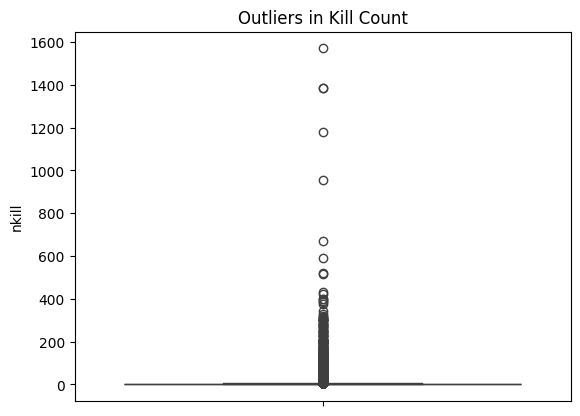

In [14]:
sns.boxplot(df['nkill'])  #outliers of my num of killed 
plt.title("Outliers in Kill Count")
plt.show()

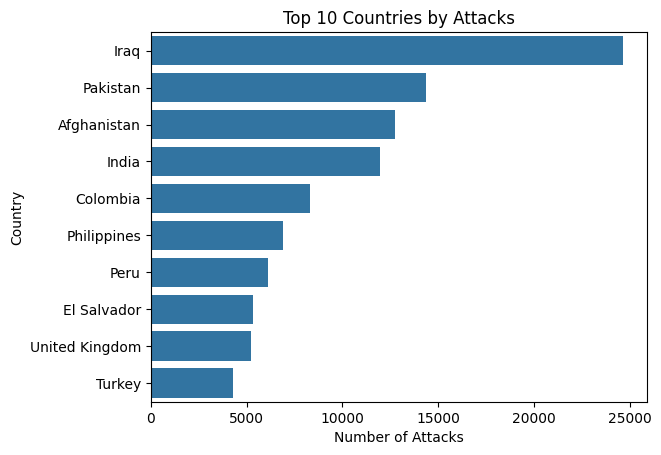

In [15]:
# bar chart
top_countries = df['country_txt'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by Attacks")
plt.xlabel("Number of Attacks")
plt.ylabel("Country")
plt.show()

In [16]:
# EDA 
# country wise attack 
# insight Iraq has the highest number of terrorist attacks = 24,636
df['country_txt'].value_counts().head(10) 

country_txt
Iraq              24636
Pakistan          14368
Afghanistan       12731
India             11960
Colombia           8306
Philippines        6908
Peru               6096
El Salvador        5320
United Kingdom     5235
Turkey             4292
Name: count, dtype: int64

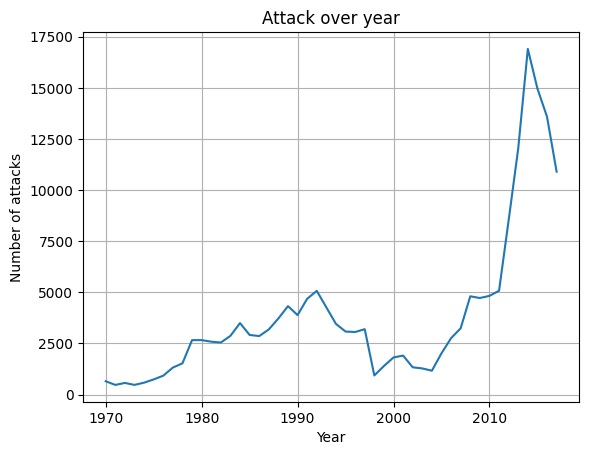

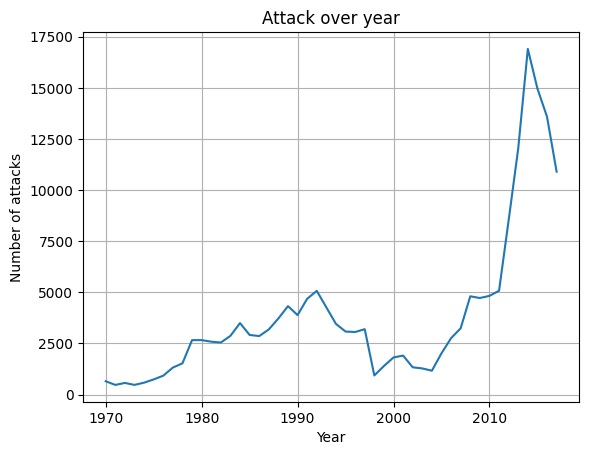

In [17]:
# Line chart
# top 10 year wise attack
df["iyear"].value_counts().sort_index().plot(kind='line')
plt.xlabel("Year")
plt.ylabel("Number of attacks")
plt.title("Attack over year")
plt.grid()
plt.show()

year_counts =df["iyear"].value_counts().sort_index()

sns.lineplot(x=year_counts.index , y=year_counts.values)
plt.xlabel("Year")
plt.ylabel("Number of attacks")
plt.title("Attack over year")
plt.grid()
plt.show()

In [18]:
#insights The highest number of attacks occurred in 2014 = 16,903
df['iyear'].value_counts().head(10)  

iyear
2014    16903
2015    14965
2016    13587
2013    12036
2017    10900
2012     8522
2011     5076
1992     5071
2010     4826
2008     4805
Name: count, dtype: int64

In [19]:
# Attack types 
# insights Bombing/Explosion is the mostly repeated attack = 88255

df['attacktype1_txt'].value_counts()  

attacktype1_txt
Bombing/Explosion                      88255
Armed Assault                          42669
Assassination                          19312
Hostage Taking (Kidnapping)            11158
Facility/Infrastructure Attack         10356
Unknown                                 7276
Unarmed Assault                         1015
Hostage Taking (Barricade Incident)      991
Hijacking                                659
Name: count, dtype: int64

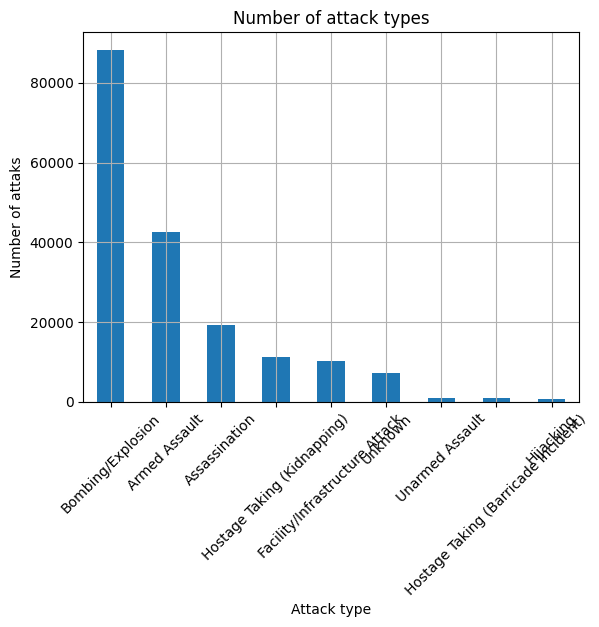

In [20]:
# Bombing is the most common attack type
df["attacktype1_txt"].value_counts().plot(kind="bar")
plt.xlabel("Attack type")
plt.ylabel("Number of attaks")
plt.title("Number of attack types")
plt.grid()
plt.xticks(rotation=45)
plt.show()

In [21]:
# group wise attack 
# insights *Taliban is one of the most active groups

df['gname'].value_counts().head(10) 

gname
Unknown                                             82782
Taliban                                              7478
Islamic State of Iraq and the Levant (ISIL)          5613
Shining Path (SL)                                    4555
Farabundo Marti National Liberation Front (FMLN)     3351
Al-Shabaab                                           3288
New People's Army (NPA)                              2772
Irish Republican Army (IRA)                          2671
Revolutionary Armed Forces of Colombia (FARC)        2487
Boko Haram                                           2418
Name: count, dtype: int64

In [22]:
# The GTA dataset shows that terrorist activities increased significantly around 2014, 
# with Iraq being the most affected country,
# Bombing was the most common attack type, 
# and groups like Taliban were highly active.

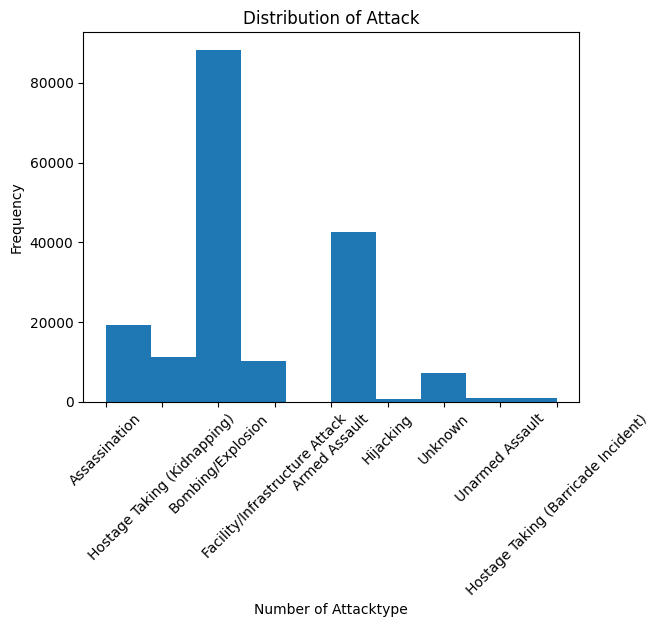

In [23]:
plt.hist(df['attacktype1_txt'], bins=10)
plt.title("Distribution of Attack")
plt.xlabel("Number of Attacktype")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [24]:
# Features & Target
# Encoding
# Logistic Regression
# Random Forest
# Random Forest


In [25]:
#features and target

X = df[['iyear','region_txt','attacktype1_txt','weaptype1_txt']]
y = df['success']


In [26]:
X = pd.get_dummies(X)  # Encoding

In [27]:
#split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [28]:
# Logistic Regression
 # max_iter=1000, Model apne weights ko baar-baar update karta hai, maximum number of training steps

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)    
lr.fit(X_train, y_train)
X_pred_lr = lr.predict(X_test)

c:\Users\hari om\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
# Random Forest Classifire
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
X_pred_rf= rf.predict(X_test)

In [30]:
# accureccy
from sklearn.metrics import accuracy_score
print("Logistic:", accuracy_score(y_test, X_pred_lr))
print("Random Forest:", accuracy_score(y_test, X_pred_rf))

Logistic: 0.8915765431079556
Random Forest: 0.8902831668455379


In [31]:
from sklearn.metrics  import confusion_matrix
print(confusion_matrix(y_test, X_pred_lr))

[[  348  3756]
 [  184 32051]]


In [32]:
from sklearn.metrics import classification_report
print("logistic:", classification_report(y_test, X_pred_lr))

logistic:               precision    recall  f1-score   support

           0       0.65      0.08      0.15      4104
           1       0.90      0.99      0.94     32235

    accuracy                           0.89     36339
   macro avg       0.77      0.54      0.55     36339
weighted avg       0.87      0.89      0.85     36339



In [33]:
# XGBoost

from xgboost import XGBClassifier
xgb =XGBClassifier(use_label_encoder=False, eval_matric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb= xgb.predict(X_test)



c:\Users\hari om\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:00:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "eval_matric", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [34]:
from sklearn.metrics import accuracy_score 
print("XGboost:", accuracy_score(y_test, y_pred_xgb))
print("XGB cnfu_mat:", confusion_matrix(y_test, y_pred_xgb))

XGboost: 0.8933652549602356
XGB cnfu_mat: [[  468  3636]
 [  239 31996]]


In [35]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
df.rename(columns={'iyear': 'year'}, inplace=True)

C:\Users\hari om\AppData\Local\Temp\ipykernel_5272\559519775.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'iyear': 'year'}, inplace=True)


In [45]:
from sklearn.preprocessing import LabelEncoder


le_region = LabelEncoder()
le_attack = LabelEncoder()
le_weapon = LabelEncoder()


df['region'] = le_region.fit_transform(df['region_txt'])
df['attack'] = le_attack.fit_transform(df['attacktype1_txt'])
df['weapon'] = le_weapon.fit_transform(df['weaptype1_txt'])

In [42]:
df.rename(columns={'iyear': 'year'}, inplace=True)
df = df[['year', 'region_txt', 'attacktype1_txt', 'weaptype1_txt', 'success']]

C:\Users\hari om\AppData\Local\Temp\ipykernel_5272\2829577726.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'iyear': 'year'}, inplace=True)


In [46]:
X = df[['year', 'region', 'attack', 'weapon']]
y = df['success']

In [50]:
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)

In [51]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    class_weight='balanced'
)

lgbm.fit(X_train, y_train)

y_pred_lgb = lgbm.predict(X_test)

[LightGBM] [Info] Number of positive: 129397, number of negative: 15955
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002317 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 112
[LightGBM] [Info] Number of data points in the train set: 145352, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


In [52]:
#[[  317  3604]   [[TN  FP]
#[  198 32220]]     [FN  TP]]


from sklearn.metrics import accuracy_score, confusion_matrix

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("LightGBM Confusion:\n", confusion_matrix(y_test, y_pred_lgb))

LightGBM Accuracy: 0.7111092765348523
LightGBM Confusion:
 [[ 2781  1323]
 [ 9175 23060]]


In [54]:
from sklearn.metrics import classification_report
print("logistic:", classification_report(y_test, y_pred_lgb))

logistic:               precision    recall  f1-score   support

           0       0.23      0.68      0.35      4104
           1       0.95      0.72      0.81     32235

    accuracy                           0.71     36339
   macro avg       0.59      0.70      0.58     36339
weighted avg       0.87      0.71      0.76     36339



In [55]:
print("XGB:", classification_report(y_test, y_pred_xgb))


XGB:               precision    recall  f1-score   support

           0       0.66      0.11      0.19      4104
           1       0.90      0.99      0.94     32235

    accuracy                           0.89     36339
   macro avg       0.78      0.55      0.57     36339
weighted avg       0.87      0.89      0.86     36339



In [56]:
print("logistic:", confusion_matrix(y_test, X_pred_lr))


logistic: [[  348  3756]
 [  184 32051]]


In [57]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
import joblib
joblib.dump(xgb, 'model.pkl')

['model.pkl']